# Factuality Metrics

Aggregates the per-row labels produced by the factuality pipeline
(`factuality_full.csv`) into paper-ready breakdowns.

Verifications covered:
1. **Author** — `author_status` ∈ {`found`, `hallucinated`}
2. **Field** — `field_status`
3. **Seniority** — `seniority_status`
4. **Location** — `location_status`
5. **Ethnicity** — `perceived_ethnicity`

Breakdowns by `model`, `field`, `location`, `language` for each, plus visual
panels (heatmaps, boxplots) and downstream analyses (prestige, long-tail,
inter-model agreement, reproducibility).

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if '../..' not in sys.path:
    sys.path.append('../..')
from libs.visuals.vis import sns_paper_style
from libs.metrics.constants import FIG_DPI

pd.set_option('display.float_format', lambda x: f'{x:.1f}')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)

sns_paper_style()

INPUT = Path('../../../results/summary_v2/factuality_full.csv')
DIMENSIONS = ['model', 'field', 'location', 'language']

# ── Clean model names for display ─────────────────────────────────────────────
def clean_model(name: str) -> str:
    return (name.replace('-q4_K_M', '')
                .replace(':q4_K_M', '')
                .replace('-instruct', '')
                .replace('-2025-04-14', '')
                .replace('-2411', '')
                .replace('-2407', '')
                .replace('-2506', '')
                .replace('-2409', ''))

In [2]:
df = pd.read_csv(INPUT, low_memory=False)
print(f'Rows: {len(df):,}   Columns: {len(df.columns)}')
df[DIMENSIONS + ['author_status', 'field_status', 'seniority_status',
                 'location_status', 'perceived_ethnicity']].head()

Rows: 3,907,448   Columns: 82


,model,field,location,language,author_status,field_status,seniority_status,location_status,perceived_ethnicity
0,gemini-2.5-flash,Mathematics,South Africa,english,found,field_match,seniority_unknown,location_match,White
1,gemini-2.5-flash,Mathematics,South Africa,english,found,field_match,seniority_mismatch,location_mismatch,Asian
2,gemini-2.5-flash,Mathematics,South Africa,english,found,field_match,seniority_mismatch,location_mismatch,White
3,gemini-2.5-flash,Mathematics,South Africa,english,hallucinated,not_applicable,not_applicable,not_applicable,White
4,gemini-2.5-flash,Mathematics,South Africa,english,found,field_match,seniority_mismatch,location_mismatch,White


## Helpers

In [3]:
def breakdown(data: pd.DataFrame, status_col: str, dim_col: str) -> pd.DataFrame:
    counts = data.groupby([dim_col, status_col]).size().unstack(fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    pct = pct.round(1)
    pct['n'] = counts.sum(axis=1)
    return pct.sort_values('n', ascending=False)


def overall(data: pd.DataFrame, status_col: str) -> pd.Series:
    counts = data[status_col].value_counts()
    pct = (counts / counts.sum() * 100).round(1)
    pct.name = f'{status_col} (% over n={len(data):,})'
    return pct


def pct_heatmap(data: pd.DataFrame, row_col: str, col_col: str,
                normalize: str = 'index', title: str = '', cmap: str = 'Blues',
                figsize: tuple = (10, 6)) -> None:
    """Cross-tab + percent-normalised heatmap."""
    ct = pd.crosstab(data[row_col], data[col_col], normalize=normalize) * 100
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(ct, annot=True, fmt='.1f', cmap=cmap, cbar_kws={'label': '%'}, ax=ax)
    ax.set_title(title or f'{row_col} × {col_col}  (row %)')
    ax.set_xlabel(col_col)
    ax.set_ylabel(row_col)
    plt.tight_layout()
    plt.show()

## 1. Author — `found` vs `hallucinated`

In [4]:
overall(df, 'author_status')

author_status
hallucinated   55.0
found          45.0
Name: author_status (% over n=3,907,448), dtype: float64

In [5]:
for dim in DIMENSIONS:
    print(f'\n=== author_status × {dim} ===')
    display(breakdown(df, 'author_status', dim))


=== author_status × model ===


author_status,found,hallucinated,n
model,,,
llama4:17b-scout-16e-instruct-q4_K_M,50.0,50.0,121885
falcon3:10b-instruct-q4_K_M,57.4,42.6,116369
mistral:7b-instruct-v0.3-q4_K_M,21.9,78.1,115816
phi4:14b-q4_K_M,49.4,50.6,115276
llama3.3:70b-instruct-q4_K_M,55.1,44.9,115202
dolphin3:8b-llama3.1-q4_K_M,44.5,55.5,115126
mistral-small3.2:24b-instruct-2506-q4_K_M,53.1,46.9,115116
gpt-4.1-2025-04-14,42.8,57.2,114943
gemini-2.5-pro,48.7,51.3,114844



=== author_status × field ===


author_status,found,hallucinated,n
field,,,
Ciencias de la computación,46.8,53.2,229746
Física,44.1,55.9,228303
Biología,44.6,55.4,227976
Sociología,41.0,59.0,227656
Psicología,41.1,58.9,226583
Matemáticas,45.2,54.8,223585
Sociology,42.6,57.4,220349
Psychology,43.6,56.4,220094
Computer Science,48.4,51.6,219919



=== author_status × location ===


author_status,found,hallucinated,n
location,,,
Ecuador,48.3,51.7,773190
Japan,74.9,25.1,513195
Japón,71.6,28.4,275768
Alemania,41.6,58.4,274207
Canadá,36.4,63.6,271601
Sudáfrica,21.2,78.8,271199
Germany,42.6,57.4,263902
Canada,37.8,62.2,262540
South Africa,23.9,76.1,262182



=== author_status × language ===


author_status,found,hallucinated,n
language,,,
spanish,43.8,56.2,1363849
english,45.7,54.3,1312843
german,45.5,54.5,1230756


## 2. Field — match vs mismatch (rows where author was `found`)

In [6]:
df_field = df[df['author_status'] == 'found'].copy()
print(f'Rows considered: {len(df_field):,}')
overall(df_field, 'field_status')

Rows considered: 1,757,396


field_status
field_mismatch   73.4
field_match      26.6
Name: field_status (% over n=1,757,396), dtype: float64

In [7]:
for dim in DIMENSIONS:
    print(f'\n=== field_status × {dim} ===')
    display(breakdown(df_field, 'field_status', dim))


=== field_status × model ===


field_status,field_match,field_mismatch,n
model,,,
falcon3:10b-instruct-q4_K_M,17.8,82.2,66829
llama3.3:70b-instruct-q4_K_M,30.4,69.6,63491
mistral-small3.2:24b-instruct-2506-q4_K_M,25.9,74.1,61144
llama4:17b-scout-16e-instruct-q4_K_M,24.6,75.4,60892
gpt-oss:120b,25.7,74.3,57700
phi4:14b-q4_K_M,22.4,77.6,56920
gemini-2.5-pro,51.1,48.9,55957
llama4:17b-maverick-128e-instruct-q4_K_M,34.9,65.1,54764
deepseek-r1:70b-llama-distill-q4_K_M,27.4,72.6,54276



=== field_status × field ===


field_status,field_match,field_mismatch,n
field,,,
Ciencias de la computación,25.8,74.2,107445
Computer Science,26.8,73.2,106353
Biology,54.5,45.5,102376
Biología,55.8,44.2,101690
Matemáticas,24.2,75.8,101145
Mathematics,25.9,74.1,101065
Física,19.5,80.5,100630
Physics,20.0,80.0,100552
Informatik,25.7,74.3,99773



=== field_status × location ===


field_status,field_match,field_mismatch,n
location,,,
Japan,26.4,73.6,384353
Ecuador,18.2,81.8,373372
Japón,26.3,73.7,197515
Alemania,31.9,68.1,114138
Germany,32.5,67.5,112503
Deutschland,31.9,68.1,103567
Canada,31.1,68.9,99263
Canadá,30.9,69.1,98820
Kanada,30.4,69.6,94365



=== field_status × language ===


field_status,field_match,field_mismatch,n
language,,,
english,26.9,73.1,600062
spanish,26.5,73.5,597443
german,26.6,73.4,559891


## 3. Seniority — match vs mismatch

In [8]:
df_sen = df[df['author_status'] == 'found'].copy()
overall(df_sen, 'seniority_status')

seniority_status
seniority_match      43.4
seniority_mismatch   33.1
seniority_unknown    23.5
Name: seniority_status (% over n=1,757,396), dtype: float64

In [9]:
for dim in DIMENSIONS:
    print(f'\n=== seniority_status × {dim} ===')
    display(breakdown(df_sen, 'seniority_status', dim))


=== seniority_status × model ===


seniority_status,seniority_match,seniority_mismatch,seniority_unknown,n
model,,,,
falcon3:10b-instruct-q4_K_M,46.2,33.9,19.9,66829
llama3.3:70b-instruct-q4_K_M,41.2,34.0,24.8,63491
mistral-small3.2:24b-instruct-2506-q4_K_M,41.3,37.5,21.3,61144
llama4:17b-scout-16e-instruct-q4_K_M,41.3,33.1,25.6,60892
gpt-oss:120b,45.6,29.0,25.3,57700
phi4:14b-q4_K_M,42.6,34.2,23.1,56920
gemini-2.5-pro,50.4,19.1,30.5,55957
llama4:17b-maverick-128e-instruct-q4_K_M,42.9,30.6,26.5,54764
deepseek-r1:70b-llama-distill-q4_K_M,40.6,34.6,24.9,54276



=== seniority_status × field ===


seniority_status,seniority_match,seniority_mismatch,seniority_unknown,n
field,,,,
Ciencias de la computación,42.7,31.7,25.7,107445
Computer Science,41.9,32.4,25.7,106353
Biology,43.1,33.8,23.1,102376
Biología,43.1,32.9,24.1,101690
Matemáticas,45.4,31.8,22.7,101145
Mathematics,44.5,33.0,22.5,101065
Física,43.3,33.1,23.6,100630
Physics,42.8,34.3,22.9,100552
Informatik,42.5,32.9,24.5,99773



=== seniority_status × location ===


seniority_status,seniority_match,seniority_mismatch,seniority_unknown,n
location,,,,
Japan,44.0,34.1,21.9,384353
Ecuador,35.3,37.1,27.5,373372
Japón,44.3,32.9,22.9,197515
Alemania,45.7,26.9,27.4,114138
Germany,45.5,27.6,26.9,112503
Deutschland,47.0,26.3,26.6,103567
Canada,46.7,34.5,18.8,99263
Canadá,46.9,32.6,20.5,98820
Kanada,46.9,34.7,18.4,94365



=== seniority_status × language ===


seniority_status,seniority_match,seniority_mismatch,seniority_unknown,n
language,,,,
english,43.1,33.5,23.4,600062
spanish,43.4,32.6,24.0,597443
german,43.8,33.1,23.1,559891


## 4. Location — match vs mismatch

In [10]:
df_loc = df[df['author_status'] == 'found'].copy()
overall(df_loc, 'location_status')

location_status
location_mismatch   45.4
location_match      34.4
location_unknown    20.2
Name: location_status (% over n=1,757,396), dtype: float64

In [11]:
for dim in DIMENSIONS:
    print(f'\n=== location_status × {dim} ===')
    display(breakdown(df_loc, 'location_status', dim))


=== location_status × model ===


location_status,location_match,location_mismatch,location_unknown,n
model,,,,
falcon3:10b-instruct-q4_K_M,33.5,57.8,8.7,66829
llama3.3:70b-instruct-q4_K_M,45.4,52.2,2.4,63491
mistral-small3.2:24b-instruct-2506-q4_K_M,41.6,56.1,2.3,61144
llama4:17b-scout-16e-instruct-q4_K_M,39.3,53.0,7.7,60892
gpt-oss:120b,48.6,47.9,3.6,57700
phi4:14b-q4_K_M,37.5,56.3,6.2,56920
gemini-2.5-pro,57.5,20.6,21.9,55957
llama4:17b-maverick-128e-instruct-q4_K_M,46.2,50.8,3.0,54764
deepseek-r1:70b-llama-distill-q4_K_M,42.7,51.4,5.9,54276



=== location_status × field ===


location_status,location_match,location_mismatch,location_unknown,n
field,,,,
Ciencias de la computación,34.9,46.5,18.6,107445
Computer Science,35.1,43.7,21.2,106353
Biology,33.8,43.6,22.6,102376
Biología,34.9,46.5,18.6,101690
Matemáticas,31.3,49.6,19.1,101145
Mathematics,30.4,46.3,23.2,101065
Física,34.6,46.5,18.9,100630
Physics,32.9,44.0,23.1,100552
Informatik,35.7,45.4,18.9,99773



=== location_status × location ===


location_status,location_match,location_mismatch,location_unknown,n
location,,,,
Japan,65.2,9.9,24.9,384353
Ecuador,2.9,89.6,7.5,373372
Japón,67.7,10.6,21.7,197515
Alemania,44.2,33.4,22.4,114138
Germany,43.5,29.9,26.6,112503
Deutschland,45.7,29.6,24.7,103567
Canada,12.7,64.1,23.2,99263
Canadá,12.4,66.8,20.8,98820
Kanada,11.8,68.5,19.7,94365



=== location_status × language ===


location_status,location_match,location_mismatch,location_unknown,n
language,,,,
english,33.8,43.9,22.3,600062
spanish,34.9,46.6,18.5,597443
german,34.5,45.9,19.6,559891


## 5. Ethnicity — distribution

In [12]:
overall(df, 'perceived_ethnicity')

perceived_ethnicity
Unknown                     47.6
Asian                       24.9
White                       11.9
Hispanic or Latino           9.5
Black or African American    6.0
Name: perceived_ethnicity (% over n=3,907,448), dtype: float64

In [13]:
for dim in DIMENSIONS:
    print(f'\n=== perceived_ethnicity × {dim} ===')
    display(breakdown(df, 'perceived_ethnicity', dim))


=== perceived_ethnicity × model ===


perceived_ethnicity,Asian,Black or African American,Hispanic or Latino,Unknown,White,n
model,,,,,,
llama4:17b-scout-16e-instruct-q4_K_M,21.6,3.2,10.2,57.9,7.1,121885
falcon3:10b-instruct-q4_K_M,36.0,5.5,11.6,36.9,10.1,116369
mistral:7b-instruct-v0.3-q4_K_M,6.0,5.1,2.9,82.6,3.3,115816
phi4:14b-q4_K_M,28.4,4.5,12.1,45.4,9.6,115276
llama3.3:70b-instruct-q4_K_M,29.5,4.7,11.9,37.5,16.4,115202
dolphin3:8b-llama3.1-q4_K_M,13.9,4.0,9.2,65.0,7.9,115126
mistral-small3.2:24b-instruct-2506-q4_K_M,29.5,6.8,14.9,36.2,12.6,115116
gpt-4.1-2025-04-14,14.9,4.3,6.1,62.3,12.4,114943
gemini-2.5-pro,30.6,9.9,15.7,10.8,33.0,114844



=== perceived_ethnicity × field ===


perceived_ethnicity,Asian,Black or African American,Hispanic or Latino,Unknown,White,n
field,,,,,,
Ciencias de la computación,24.7,6.9,11.4,45.3,11.7,229746
Física,25.6,6.3,10.3,47.4,10.4,228303
Biología,26.3,6.4,10.5,46.1,10.7,227976
Sociología,24.5,6.8,9.9,48.0,10.9,227656
Psicología,23.3,6.3,9.5,48.8,12.1,226583
Matemáticas,25.2,6.2,10.0,46.2,12.4,223585
Sociology,24.1,6.2,8.6,49.8,11.3,220349
Psychology,23.3,5.6,8.4,50.5,12.2,220094
Computer Science,24.3,5.7,10.2,47.9,12.0,219919



=== perceived_ethnicity × location ===


perceived_ethnicity,Asian,Black or African American,Hispanic or Latino,Unknown,White,n
location,,,,,,
Ecuador,15.6,0.6,37.4,46.0,0.4,773190
Japan,60.1,0.5,0.4,38.4,0.5,513195
Japón,59.9,0.9,0.9,37.7,0.5,275768
Alemania,8.2,1.5,4.9,53.1,32.3,274207
Canadá,26.0,7.1,5.7,45.3,15.8,271601
Sudáfrica,14.3,22.3,2.5,52.8,8.0,271199
Germany,6.9,1.4,3.3,56.1,32.2,263902
Canada,25.3,7.3,3.0,47.7,16.8,262540
South Africa,15.1,18.5,1.5,56.2,8.7,262182



=== perceived_ethnicity × language ===


perceived_ethnicity,Asian,Black or African American,Hispanic or Latino,Unknown,White,n
language,,,,,,
spanish,24.9,6.5,10.3,47.0,11.4,1363849
english,24.5,5.6,8.9,49.3,11.7,1312843
german,25.4,6.0,9.3,46.6,12.7,1230756


## 6. Fully correct rows

A row is *fully correct* iff `author_status == 'found'` AND field/seniority/location all match.
Rows with any `unknown` are excluded from the denominator.

In [14]:
evaluable = df[
    (df['author_status']  == 'found')
    & df['field_status'].isin(['field_match', 'field_mismatch'])
    & df['seniority_status'].isin(['seniority_match', 'seniority_mismatch'])
    & df['location_status'].isin(['location_match', 'location_mismatch'])
].copy()

evaluable['fully_correct'] = (
    (evaluable['field_status']     == 'field_match')
    & (evaluable['seniority_status'] == 'seniority_match')
    & (evaluable['location_status']  == 'location_match')
)

print(f'Evaluable rows: {len(evaluable):,} / {len(df):,}')
print(f'Fully correct: {evaluable["fully_correct"].sum():,}  ({evaluable["fully_correct"].mean()*100:.1f}%)')

Evaluable rows: 1,075,083 / 3,907,448
Fully correct: 98,007  (9.1%)


In [15]:
for dim in DIMENSIONS:
    print(f'\n=== fully_correct × {dim} ===')
    g = evaluable.groupby(dim)['fully_correct']
    out = pd.DataFrame({
        'pct_fully_correct': (g.mean() * 100).round(1),
        'n':                 g.size(),
    }).sort_values('n', ascending=False)
    display(out)


=== fully_correct × model ===


,pct_fully_correct,n
model,,
falcon3:10b-instruct-q4_K_M,3.7,48410
mistral-small3.2:24b-instruct-2506-q4_K_M,8.4,47161
llama3.3:70b-instruct-q4_K_M,12.5,46609
mistral-large:123b-instruct-2411-q4_K_M,13.3,42026
llama4:17b-scout-16e-instruct-q4_K_M,6.9,41893
gpt-oss:120b,10.7,41749
phi4:14b-q4_K_M,5.6,41099
dolphin-mixtral:8x7b-v2.7-q4_K_M,2.5,39630
llama4:17b-maverick-128e-instruct-q4_K_M,14.0,39397



=== fully_correct × field ===


,pct_fully_correct,n
field,,
Ciencias de la computación,8.6,65086
Matemáticas,10.2,63058
Biología,13.6,62840
Física,9.8,62507
Computer Science,8.5,62341
Informatik,8.5,61195
Biology,13.5,61083
Mathematics,9.9,59879
Physics,9.0,59631



=== fully_correct × location ===


,pct_fully_correct,n
location,,
Ecuador,0.6,251178
Japan,13.8,225926
Japón,14.3,119969
Alemania,16.4,64169
Canada,6.6,62231
Canadá,6.9,62102
Kanada,6.1,62030
Germany,16.2,60291
Deutschland,17.5,57371



=== fully_correct × language ===


,pct_fully_correct,n
language,,
spanish,9.3,370809
english,8.9,357379
german,9.2,346895


## 7. Heatmap — Ethnicity × Location

Para cada país solicitado, qué etnicidades percibidas predominan.

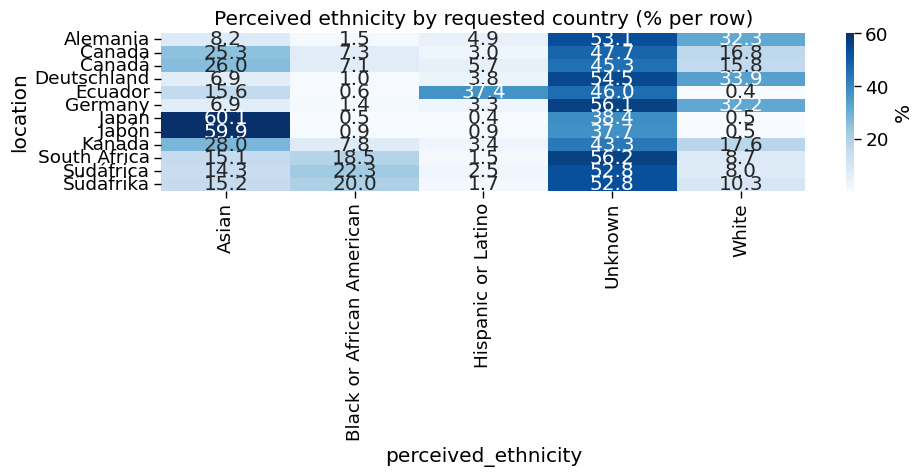

In [16]:
pct_heatmap(df, row_col='location', col_col='perceived_ethnicity',
            title='Perceived ethnicity by requested country (% per row)',
            cmap='Blues', figsize=(10, 5))

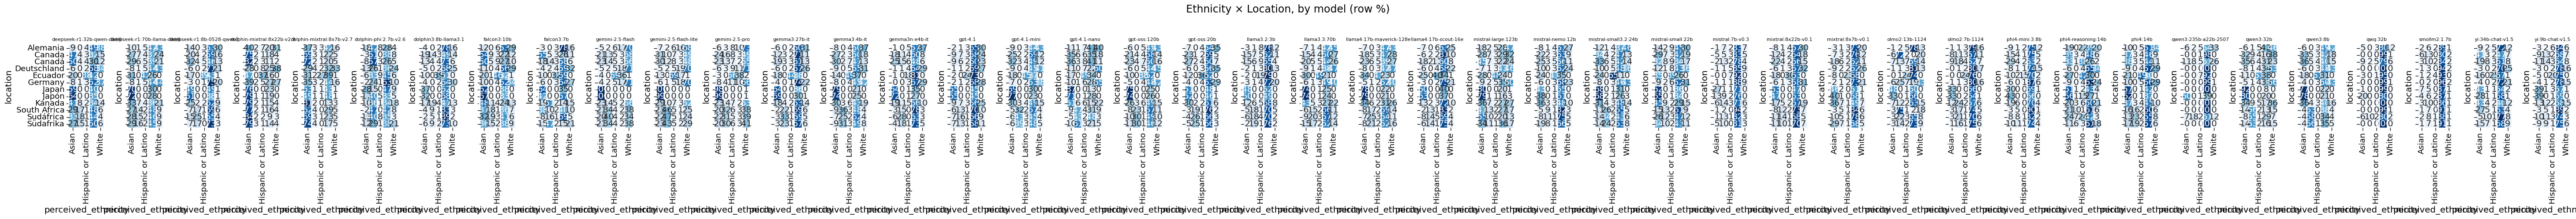

In [17]:
# Same heatmap, faceted by model
models = sorted(df['model'].dropna().unique())
fig_w = min(6 * len(models), 60)  # cap at 60 inches to avoid OOM
fig, axes = plt.subplots(1, len(models), figsize=(fig_w, 5), sharey=True)
if len(models) == 1: axes = [axes]
for ax, m in zip(axes, models):
    sub = df[df['model'] == m]
    ct = pd.crosstab(sub['location'], sub['perceived_ethnicity'], normalize='index') * 100
    sns.heatmap(ct, annot=True, fmt='.0f', cmap='Blues', cbar=False, ax=ax)
    ax.set_title(clean_model(m), fontsize=8); ax.set_xlabel('perceived_ethnicity')
axes[0].set_ylabel('location')
fig.suptitle('Ethnicity × Location, by model (row %)', y=1.02)
plt.tight_layout(); plt.show()

## 8. Heatmap — Requested country × Real country (`oa_country_code`)

Diagonal = match. Off-diagonal = mismatch. Te dice cuándo el modelo recomienda autores
de **otro** país en lugar del solicitado.

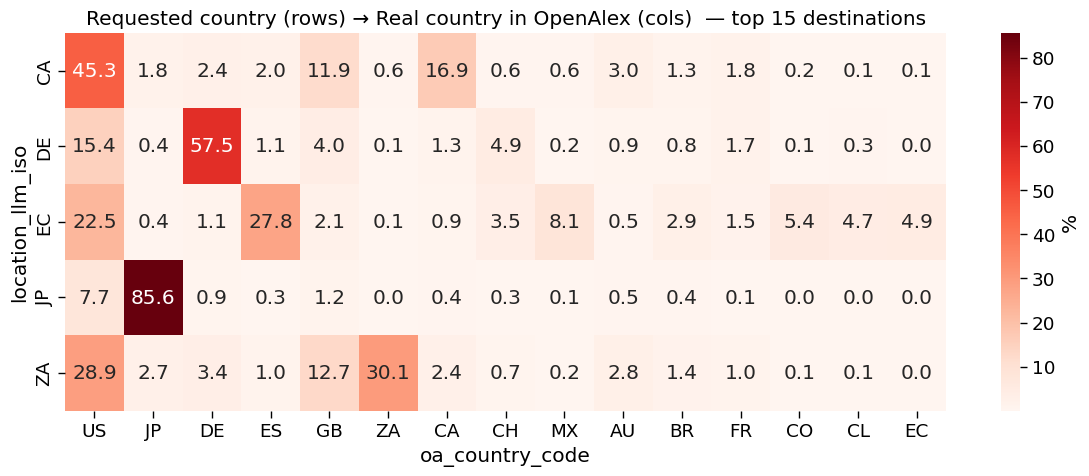

In [18]:
loc_df = df[df['oa_country_code'].notna() & df['location_llm_iso'].notna()].copy()
ct = pd.crosstab(loc_df['location_llm_iso'], loc_df['oa_country_code'], normalize='index') * 100
# Trim to the top-15 destination countries to keep the chart readable
top_dest = ct.sum(axis=0).sort_values(ascending=False).head(15).index
ct = ct[top_dest]
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Reds', cbar_kws={'label': '%'}, ax=ax)
ax.set_title('Requested country (rows) → Real country in OpenAlex (cols)  — top 15 destinations')
plt.tight_layout(); plt.show()

## 9. Career age vs requested seniority

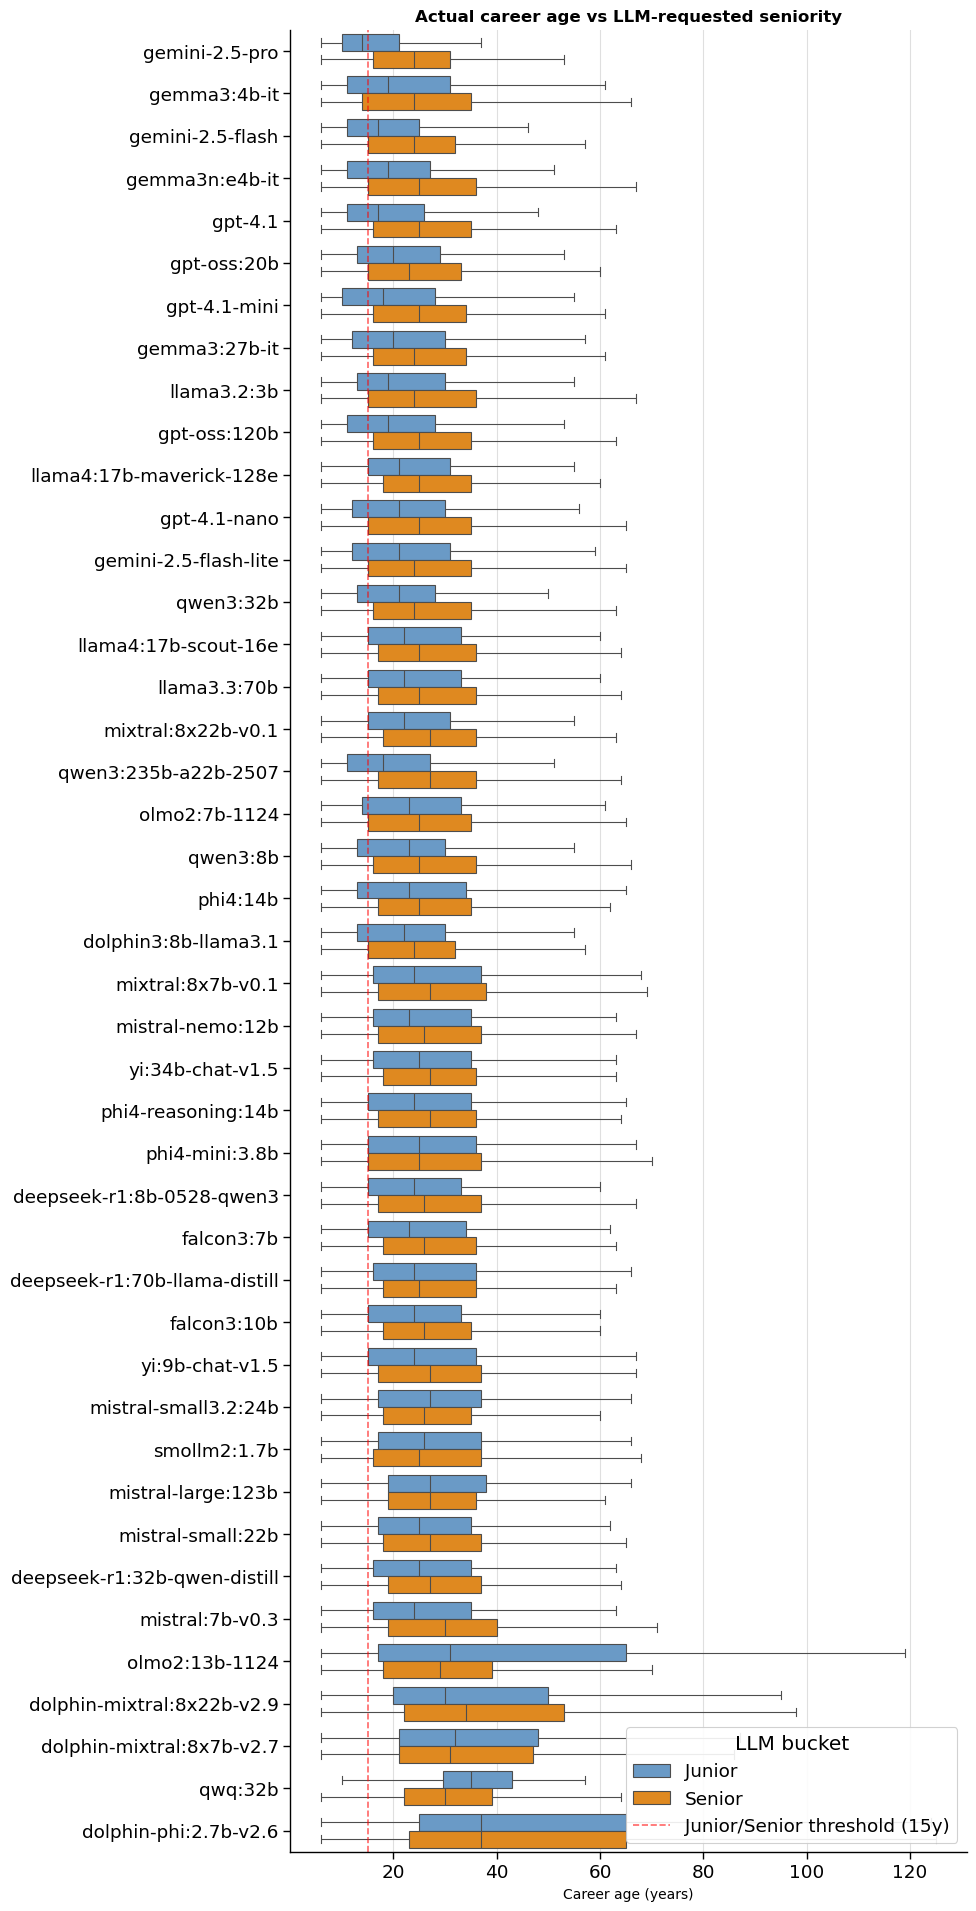

In [19]:
sen = df[df['seniority_career_age'].notna() & df['seniority_llm_bucket'].notna()].copy()
sen['model_clean'] = sen['model'].map(clean_model)

model_order_sen = (sen.groupby('model_clean')['seniority_career_age']
                   .median().sort_values().index.tolist())

fig, ax = plt.subplots(figsize=(10, max(6, len(model_order_sen) * 0.45)))
sns.boxplot(data=sen, y='model_clean', x='seniority_career_age',
            hue='seniority_llm_bucket', order=model_order_sen,
            orient='h', showfliers=False, linewidth=0.8,
            palette={'Junior': '#5B9BD5', 'Senior': '#FF8C00'}, ax=ax)
ax.axvline(15, color='red', linestyle='--', alpha=0.6, linewidth=1.2,
           label='Junior/Senior threshold (15y)')
ax.set_xlabel('Career age (years)', fontsize=10)
ax.set_ylabel('')
ax.set_title('Actual career age vs LLM-requested seniority',
             fontsize=12, fontweight='bold')
ax.legend(title='LLM bucket', loc='lower right', framealpha=0.9)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

In [20]:
# Median career age table
sen.groupby(['model', 'seniority_llm_bucket'])['seniority_career_age'].agg(['median', 'mean', 'count']).round(1)

median  mean  count
model                                seniority_llm_bucket                     
deepseek-r1:32b-qwen-distill-q4_K_M  Junior                  25.0  28.3  21613
                                     Senior                  27.0  31.0  24103
deepseek-r1:70b-llama-distill-q4_K_M Junior                  24.0  30.2  25894
                                     Senior                  25.0  29.6  28382
deepseek-r1:8b-0528-qwen3-q4_K_M     Junior                  24.0  26.8   9279
...                                                           ...   ...    ...
smollm2:1.7b-instruct-q4_K_M         Senior                  25.0  28.0  10768
yi:34b-chat-v1.5-q4_K_M              Junior                  25.0  27.7  20974
                                     Senior                  27.0  29.2  20920
yi:9b-chat-v1.5-q4_K_M               Junior                  24.0  28.0  15820
                                     Senior                  27.0  29.8  17474

[86 rows x 3 columns]

## 10. Prestige — h-index, citations, works

¿Los modelos recomiendan superestrellas o investigadores promedio?

In [21]:
prestige_cols = ['oa_h_index', 'oa_cited_by_count', 'oa_works_count', 'oa_career_age']
df[prestige_cols].describe(percentiles=[.25, .5, .75, .9, .99]).round(1)

,oa_h_index,oa_cited_by_count,oa_works_count,oa_career_age
count,0.0,2367183.0,2367183.0,2367074.0
mean,NaN,10243.3,212.0,46.7
std,NaN,31189.2,848.1,39.1
min,NaN,0.0,1.0,0.0
25%,NaN,505.0,31.0,23.0
50%,NaN,2649.0,106.0,40.0
75%,NaN,8337.0,261.0,60.0
90%,NaN,22837.0,501.0,85.0
99%,NaN,111001.0,1401.0,175.0
max,NaN,806290.0,346577.0,2036.0


In [22]:
agg = df.groupby('model')[prestige_cols].agg(['median', 'mean']).round(1)
agg

oa_h_index      oa_cited_by_count         oa_works_count       oa_career_age     
                                              median mean            median    mean         median  mean        median mean
model                                                                                                                      
deepseek-r1:32b-qwen-distill-q4_K_M              NaN  NaN            3301.0 11563.3          117.0 221.9          44.0 51.0
deepseek-r1:70b-llama-distill-q4_K_M             NaN  NaN            3697.0 11702.4          128.0 231.5          41.0 48.9
deepseek-r1:8b-0528-qwen3-q4_K_M                 NaN  NaN            3134.0 13507.3          123.0 244.2          42.0 48.2
dolphin-mixtral:8x22b-v2.9-q4_K_M                NaN  NaN            4476.0 12942.8          129.0 268.6          56.0 72.9
dolphin-mixtral:8x7b-v2.7-q4_K_M                 NaN  NaN            5016.0 16540.9          148.0 251.1          57.0 74.3
dolphin-phi:2.7b-v2.6-q4_K_M                     NaN  NaN             712.0  5269.1           37.0 124.7          37.0 49.8
dolphin3:8b-llama3.1-q4_K_M                      NaN  NaN            1392.0  4735.3           69.0 144.9          37.0 48.3
falcon3:10b-instruct-q4_K_M                      NaN  NaN            2954.0  8960.5           99.0 203.3          48.0 56.6
falcon3:7b-instruct-q4_K_M                       NaN  NaN            2905.0  8179.3           96.0 241.9          46.0 52.5
gemini-2.5-flash                                 NaN  NaN            1737.5  8011.9           96.0 186.4          33.0 37.2
gemini-2.5-flash-lite                            NaN  NaN            1910.0  9626.9           90.0 214.9          36.0 39.6
gemini-2.5-pro                                   NaN  NaN            1292.0  7138.7           81.0 159.6          30.0 33.8
gemma3:27b-it-q4_K_M                             NaN  NaN            1905.0  9351.7           90.0 207.2          36.0 40.0
gemma3:4b-it-q4_K_M                              NaN  NaN            2674.0  9221.6           98.0 227.7          41.0 44.8
gemma3n:e4b-it-q4_K_M                            NaN  NaN             114.0  2039.3           13.0  73.0          16.0 22.0
gpt-4.1-2025-04-14                               NaN  NaN            1545.0  7455.6           85.0 173.2          33.0 36.7
gpt-4.1-mini-2025-04-14                          NaN  NaN            2046.0  7587.2           88.0 185.5          39.0 42.5
gpt-4.1-nano-2025-04-14                          NaN  NaN            2449.0  8911.0           95.0 196.4          42.0 44.5
gpt-oss:120b                                     NaN  NaN            2388.0  9703.7          107.0 222.9          40.0 43.3
gpt-oss:20b                                      NaN  NaN            2504.0  8893.1          104.0 204.1          41.0 44.9
llama3.2:3b-instruct-q4_K_M                      NaN  NaN             523.0  3986.5           41.0 135.1          29.0 33.4
llama3.3:70b-instruct-q4_K_M                     NaN  NaN            2843.0 11183.1          119.0 214.2          38.0 43.1
llama4:17b-maverick-128e-instruct-q4_K_M         NaN  NaN            3279.0  9375.2          124.0 223.7          37.0 41.9
llama4:17b-scout-16e-instruct-q4_K_M             NaN  NaN            2735.0  9054.4          115.0 213.3          39.0 42.9
mistral-large:123b-instruct-2411-q4_K_M          NaN  NaN            4476.0 14422.2          146.0 264.0          46.0 54.1
mistral-nemo:12b-instruct-2407-q4_K_M            NaN  NaN            2924.0 10066.7          105.0 186.4          40.0 46.7
mistral-small3.2:24b-instruct-2506-q4_K_M        NaN  NaN            3144.0 12269.6          124.0 229.2          41.0 47.2
mistral-small:22b-instruct-2409-q4_K_M           NaN  NaN            3927.0 12503.8          119.0 223.6          46.0 54.7
mistral:7b-instruct-v0.3-q4_K_M                  NaN  NaN             525.5  5678.7           33.0 123.3          29.0 35.6
mixtral:8x22b-instruct-v0.1-q4_K_M               NaN  NaN            2905.

/tmp/ipykernel_4070002/4092375384.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y='model', x=col, order=model_order,
/tmp/ipykernel_4070002/4092375384.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y='model', x=col, order=model_order,
/tmp/ipykernel_4070002/4092375384.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, y='model', x=col, order=model_order,


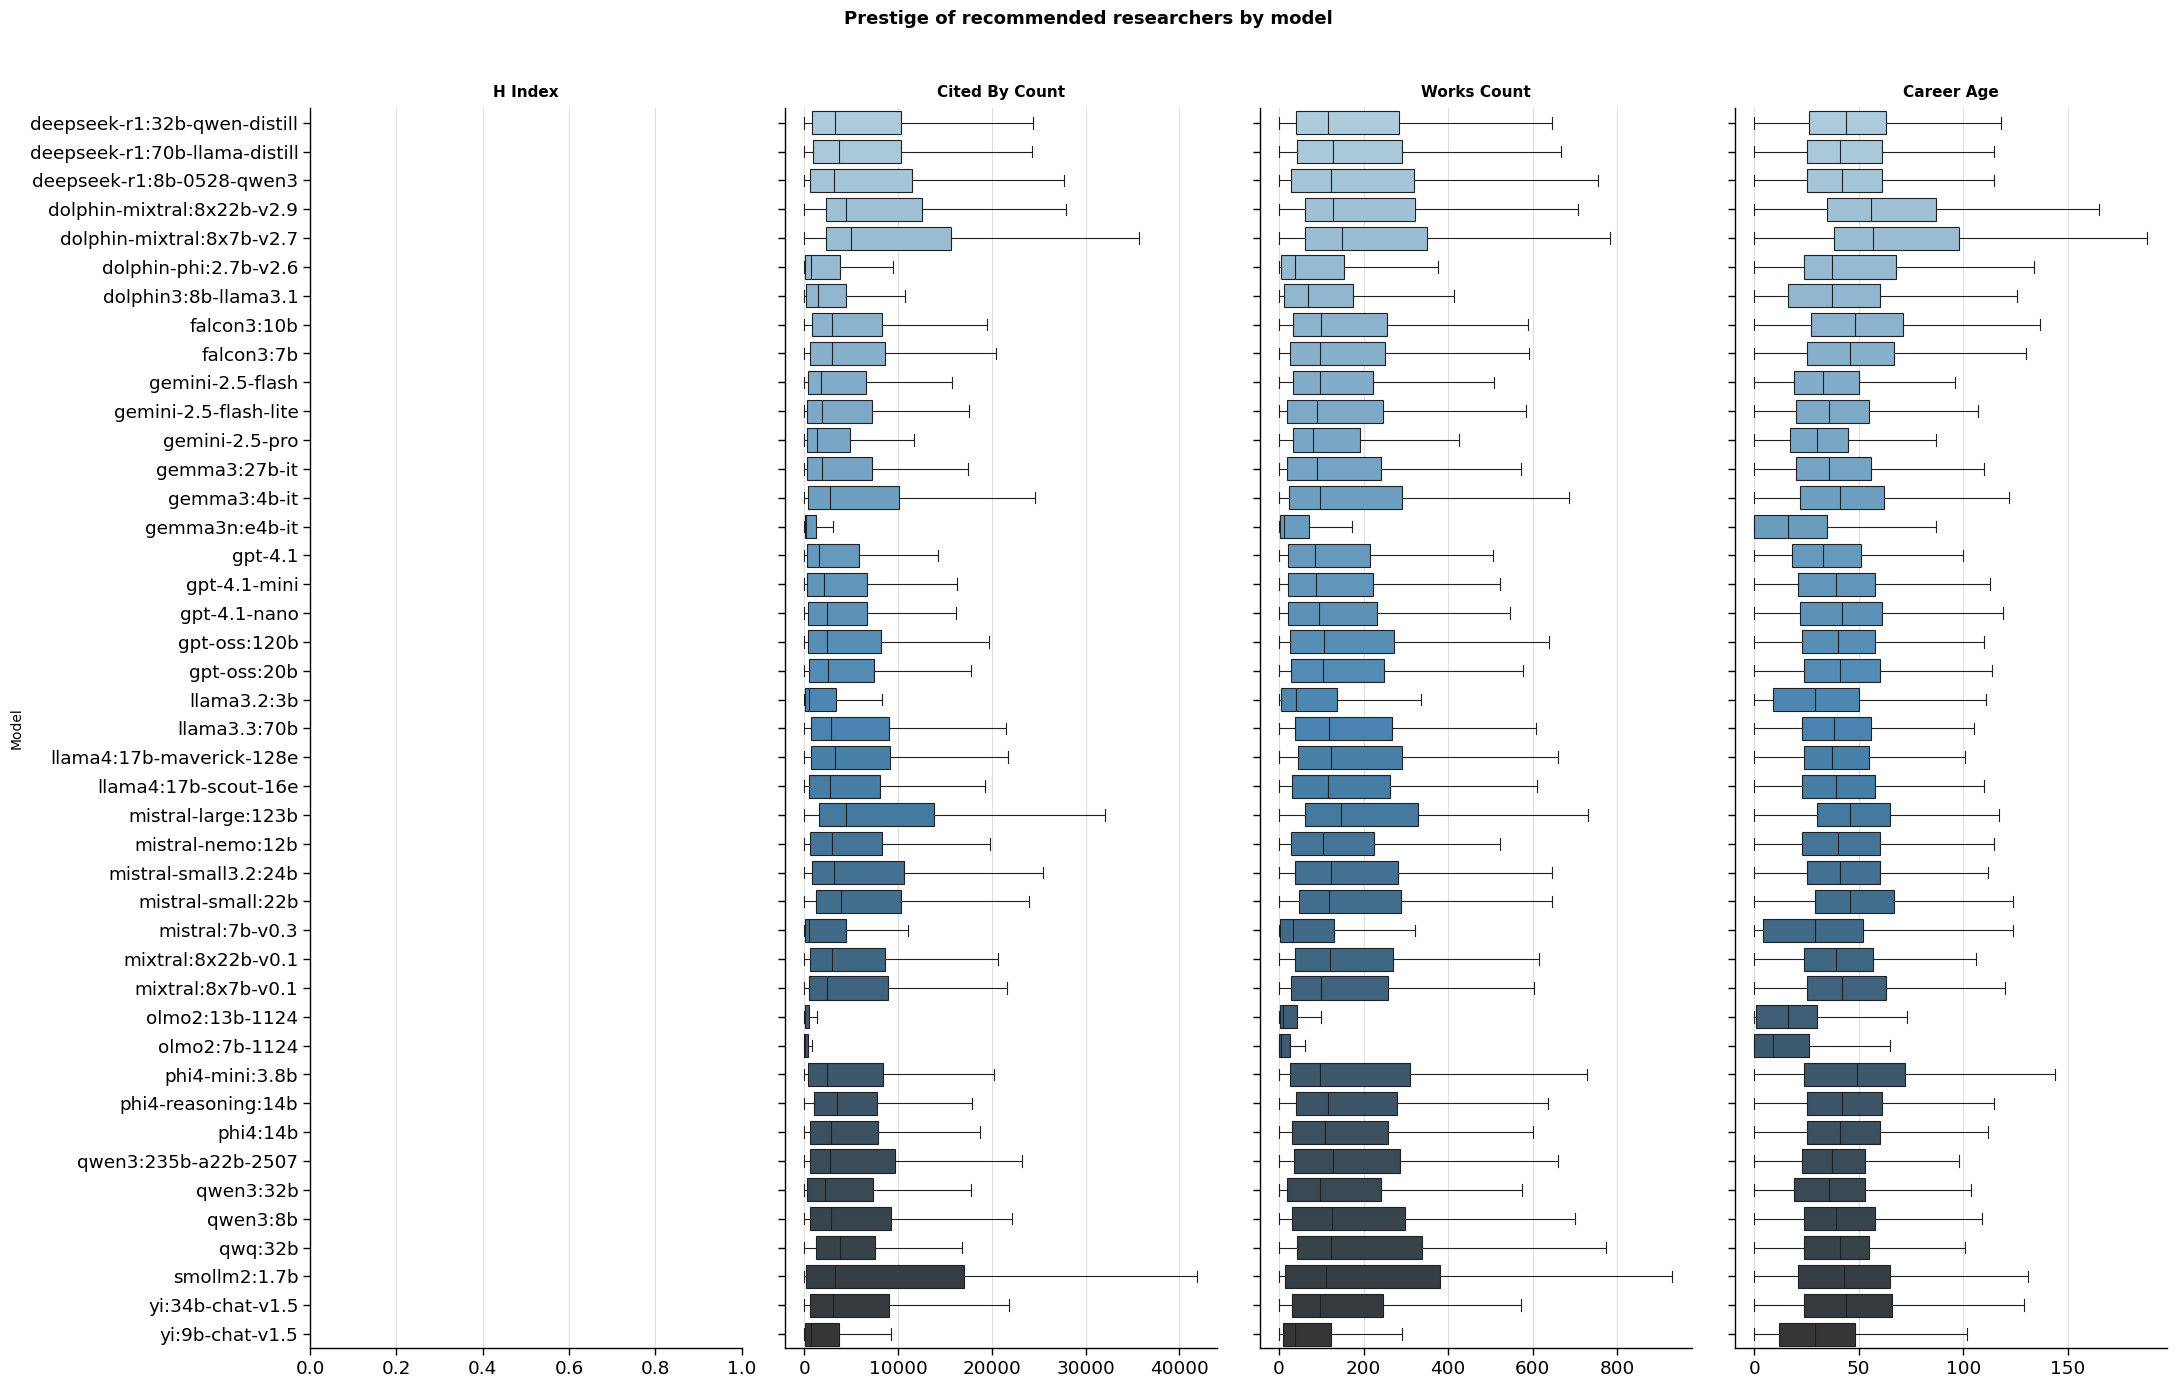

In [23]:
plot_df = df.copy()
plot_df['model'] = plot_df['model'].map(clean_model)

# Order models by median h_index descending
model_order = (plot_df.groupby('model')['oa_h_index']
               .median().sort_values(ascending=False).index.tolist())

fig, axes = plt.subplots(1, 4, figsize=(22, max(6, len(model_order) * 0.32)),
                         sharey=True)
fig.subplots_adjust(wspace=0.08)

palette = sns.color_palette('Blues_d', n_colors=len(model_order))

for ax, col in zip(axes, prestige_cols):
    data = plot_df[['model', col]].dropna(subset=[col])
    sns.boxplot(data=data, y='model', x=col, order=model_order,
                orient='h', palette=palette, showfliers=False,
                linewidth=0.8, ax=ax)
    ax.set_title(col.replace('oa_', '').replace('_', ' ').title(),
                 fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('')
    ax.set_ylabel('')
    if ax != axes[0]:
        ax.tick_params(labelleft=False)
    ax.grid(axis='x', alpha=0.4)

axes[0].set_ylabel('Model', fontsize=10)
fig.suptitle('Prestige of recommended researchers by model',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 11. Long-tail — most-recommended authors

In [24]:
author_counts = (df.dropna(subset=['name', 'lastname'])
                   .groupby(['name', 'lastname']).size()
                   .sort_values(ascending=False))
print(f'Unique authors: {len(author_counts):,}')
print(f'Total recommendations: {author_counts.sum():,}')
print(f'Authors appearing only once: {(author_counts == 1).sum():,}  ({(author_counts == 1).mean()*100:.1f}%)')
print(f'Top 1% of authors account for {author_counts.head(int(len(author_counts)*0.01)).sum() / author_counts.sum() * 100:.1f}% of recommendations')
author_counts.head(20)

Unique authors: 1,096,377
Total recommendations: 3,731,443
Authors appearing only once: 843,209  (76.9%)
Top 1% of authors account for 45.2% of recommendations


name      lastname 
John      Doe          23714
Juan      Perez        16815
Jane      Smith        13949
Maria     Rodriguez     9436
John      Smith         9161
Michael   Brown         9003
Jane      Doe           8920
Maria     Garcia        8853
Anna      Muller        8392
          Schmidt       7460
John Doe  Doe           7014
Maria     Gonzalez      6479
John Doe  Smith         6430
Emily     Johnson       5660
Michael   Johnson       5402
Carlos    Rodriguez     4858
Yoshua    Bengio        4843
Sarah     Johnson       4621
Ana       Garcia        4547
Maria     Lopez         4257
dtype: int64

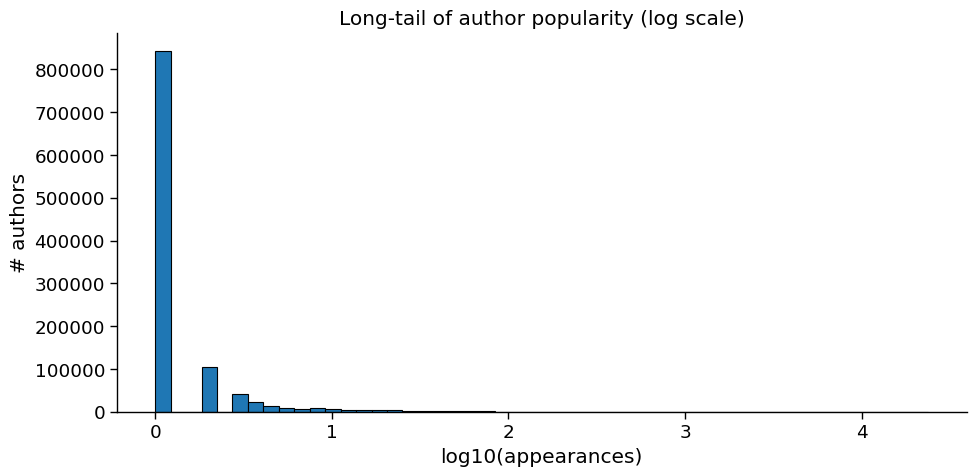

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(np.log10(author_counts.values), bins=50, edgecolor='black')
ax.set_xlabel('log10(appearances)')
ax.set_ylabel('# authors')
ax.set_title('Long-tail of author popularity (log scale)')
plt.tight_layout(); plt.show()

## 12. Inter-model agreement (Jaccard)

Para cada par de modelos, qué fracción de autores únicos es compartida.

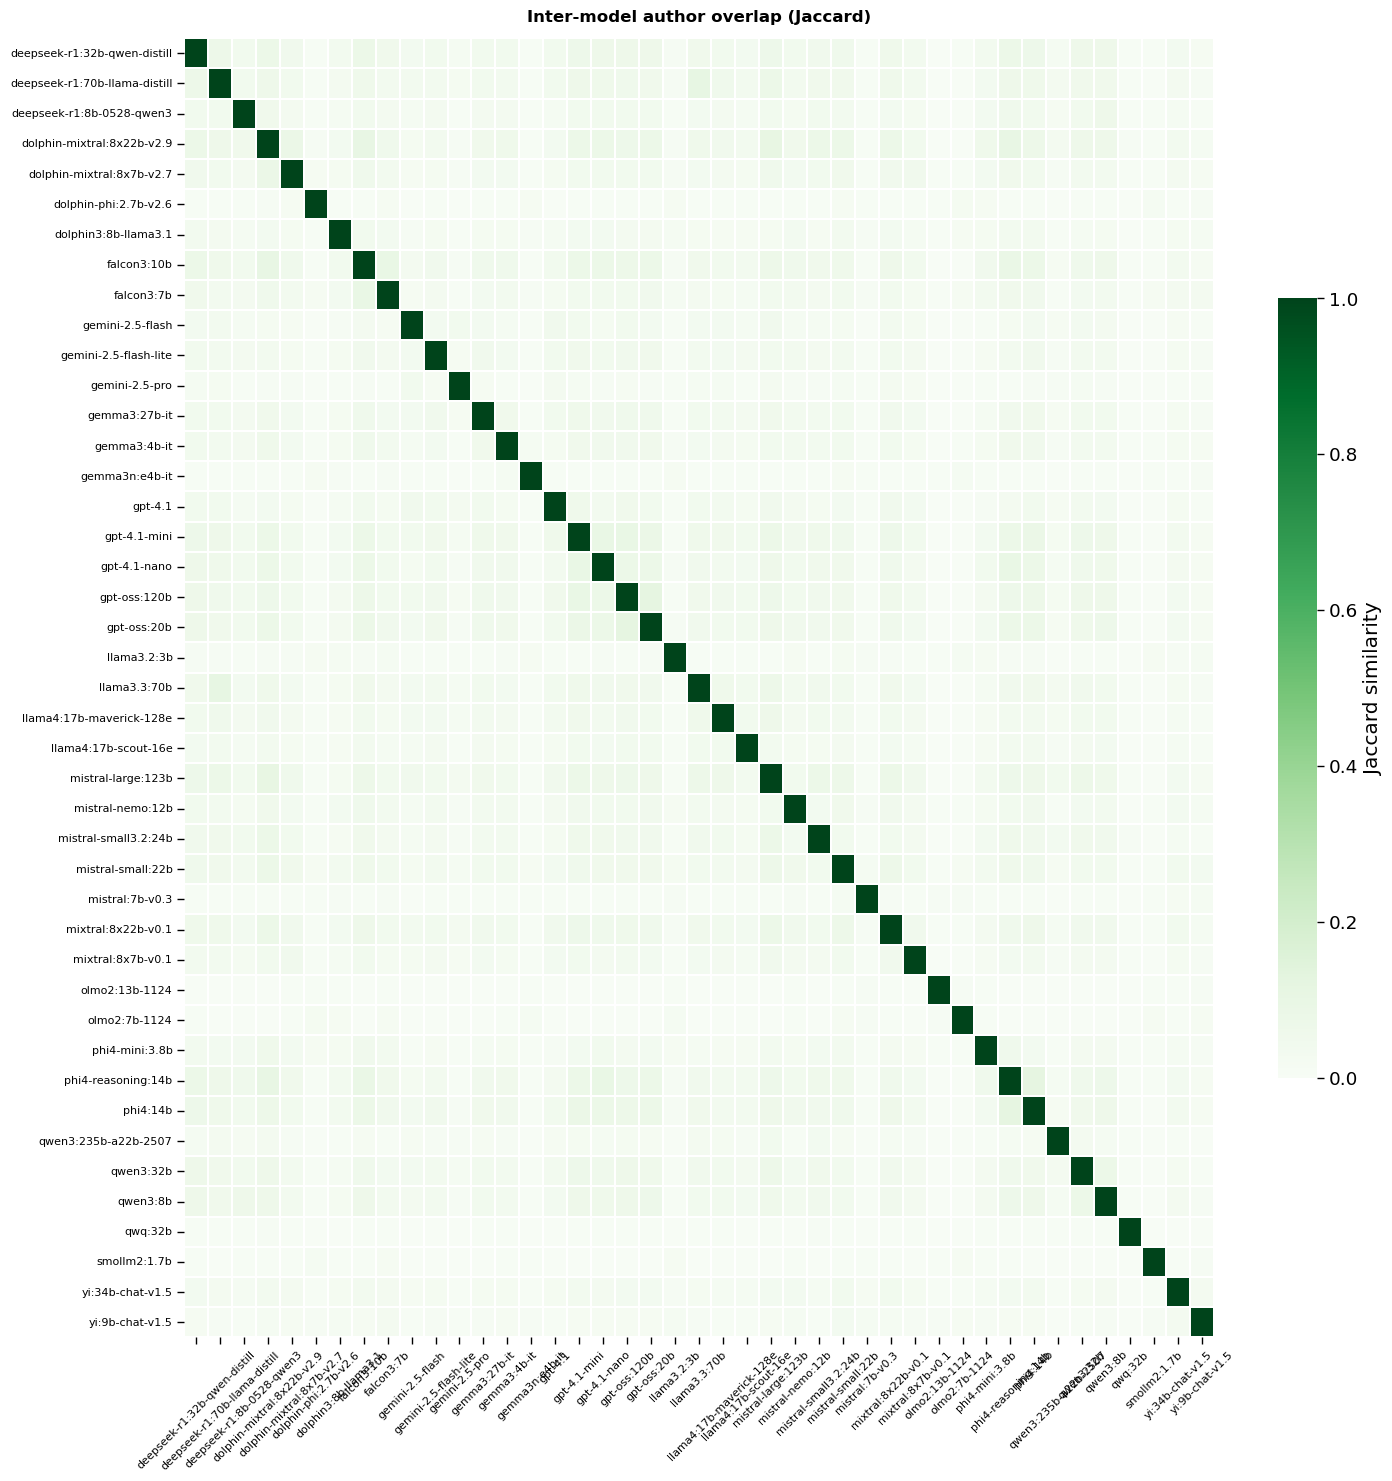

,deepseek-r1:32b-qwen-distill,deepseek-r1:70b-llama-distill,deepseek-r1:8b-0528-qwen3,dolphin-mixtral:8x22b-v2.9,dolphin-mixtral:8x7b-v2.7,dolphin-phi:2.7b-v2.6,dolphin3:8b-llama3.1,falcon3:10b,falcon3:7b,gemini-2.5-flash,gemini-2.5-flash-lite,gemini-2.5-pro,gemma3:27b-it,gemma3:4b-it,gemma3n:e4b-it,...,mistral:7b-v0.3,mixtral:8x22b-v0.1,mixtral:8x7b-v0.1,olmo2:13b-1124,olmo2:7b-1124,phi4-mini:3.8b,phi4-reasoning:14b,phi4:14b,qwen3:235b-a22b-2507,qwen3:32b,qwen3:8b,qwq:32b,smollm2:1.7b,yi:34b-chat-v1.5,yi:9b-chat-v1.5
deepseek-r1:32b-qwen-distill,1.0,0.1,0.0,0.1,0.0,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0
deepseek-r1:70b-llama-distill,0.1,1.0,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0
deepseek-r1:8b-0528-qwen3,0.0,0.0,1.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0
dolphin-mixtral:8x22b-v2.9,0.1,0.1,0.1,1.0,0.1,0.0,0.0,0.1,0.1,0.0,0.0,0.0,0.1,0.1,0.0,...,0.0,0.1,0.0,0.0,0.0,0.1,0.1,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0
dolphin-mixtral:8x7b-v2.7,0.0,0.0,0.0,0.1,1.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dolphin-phi:2.7b-v2.6,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
dolphin3:8b-llama3.1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
falcon3:10b,0.1,0.1,0.0,0.1,0.1,0.0,0.0,1.0,0.1,0.0,0.0,0.0,0.1,0.1,0.0,...,0.0,0.1,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.1,0.0,0.0,0.0,0.0
falcon3:7b,0.1,0.0,0.0,0.1,0.0,0.0,0.0,0.1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
gemini-2.5-flash,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
# Build per-model author sets (needed for Jaccard matrix)
model_authors = {
    m: set(zip(g['name'].dropna(), g['lastname'].dropna()))
    for m, g in df.dropna(subset=['name', 'lastname']).groupby('model')
}

model_authors_clean = {
    clean_model(m): authors
    for m, authors in model_authors.items()
}
models_clean = sorted(model_authors_clean)
jacc = pd.DataFrame(index=models_clean, columns=models_clean, dtype=float)
for a in models_clean:
    for b in models_clean:
        sa, sb = model_authors_clean[a], model_authors_clean[b]
        union = sa | sb
        jacc.loc[a, b] = len(sa & sb) / len(union) if union else 0.0
jacc = jacc.astype(float).round(3)

n = len(models_clean)
fig, ax = plt.subplots(figsize=(max(10, n * 0.35), max(8, n * 0.35)))
sns.heatmap(jacc, annot=(n <= 20), fmt='.2f', cmap='Greens',
            vmin=0, vmax=1, linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Jaccard similarity', 'shrink': 0.6})
ax.set_title('Inter-model author overlap (Jaccard)', fontsize=12, fontweight='bold', pad=12)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.show()
jacc

## 13. Reproducibility between runs (same prompt, different `run_id`)

Para cada combinación de prompt (model, role, task, target, field, location, language),
agrupamos los autores devueltos por `run_id` y calculamos la similitud media (Jaccard)
entre runs distintos. `≈ 1` → modelo determinista; `≈ 0` → muy variable.

In [27]:
PROMPT_KEYS = ['model', 'role', 'task', 'target', 'field', 'subfield', 'location', 'language']

def jaccard(a: set, b: set) -> float:
    u = a | b
    return len(a & b) / len(u) if u else 0.0

rep_rows = []
sub = df.dropna(subset=['name', 'lastname', 'run_id']).copy()
sub['__author'] = list(zip(sub['name'], sub['lastname']))

for keys, g in sub.groupby(PROMPT_KEYS, dropna=False):
    runs = {rid: set(rg['__author']) for rid, rg in g.groupby('run_id')}
    if len(runs) < 2:
        continue
    rids = list(runs.keys())
    pair_scores = [
        jaccard(runs[rids[i]], runs[rids[j]])
        for i in range(len(rids))
        for j in range(i + 1, len(rids))
    ]
    rep_rows.append({**dict(zip(PROMPT_KEYS, keys)),
                     'n_runs':     len(rids),
                     'mean_jaccard': sum(pair_scores) / len(pair_scores)})

rep_df = pd.DataFrame(rep_rows)
print(f'Prompt cells with ≥ 2 runs: {len(rep_df):,}')
rep_df.groupby('model')['mean_jaccard'].agg(['mean', 'median', 'count']).round(3)

Prompt cells with ≥ 2 runs: 29,971


,mean,median,count
model,,,
deepseek-r1:32b-qwen-distill-q4_K_M,0.0,0.0,720
deepseek-r1:70b-llama-distill-q4_K_M,0.1,0.1,720
deepseek-r1:8b-0528-qwen3-q4_K_M,0.0,0.0,720
dolphin-mixtral:8x22b-v2.9-q4_K_M,0.1,0.1,720
dolphin-mixtral:8x7b-v2.7-q4_K_M,0.1,0.1,720
dolphin-phi:2.7b-v2.6-q4_K_M,0.1,0.1,720
dolphin3:8b-llama3.1-q4_K_M,0.0,0.0,720
falcon3:10b-instruct-q4_K_M,0.0,0.0,720
falcon3:7b-instruct-q4_K_M,0.0,0.0,720


/tmp/ipykernel_4070002/3185128118.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rep_df, y='model_clean', x='mean_jaccard',


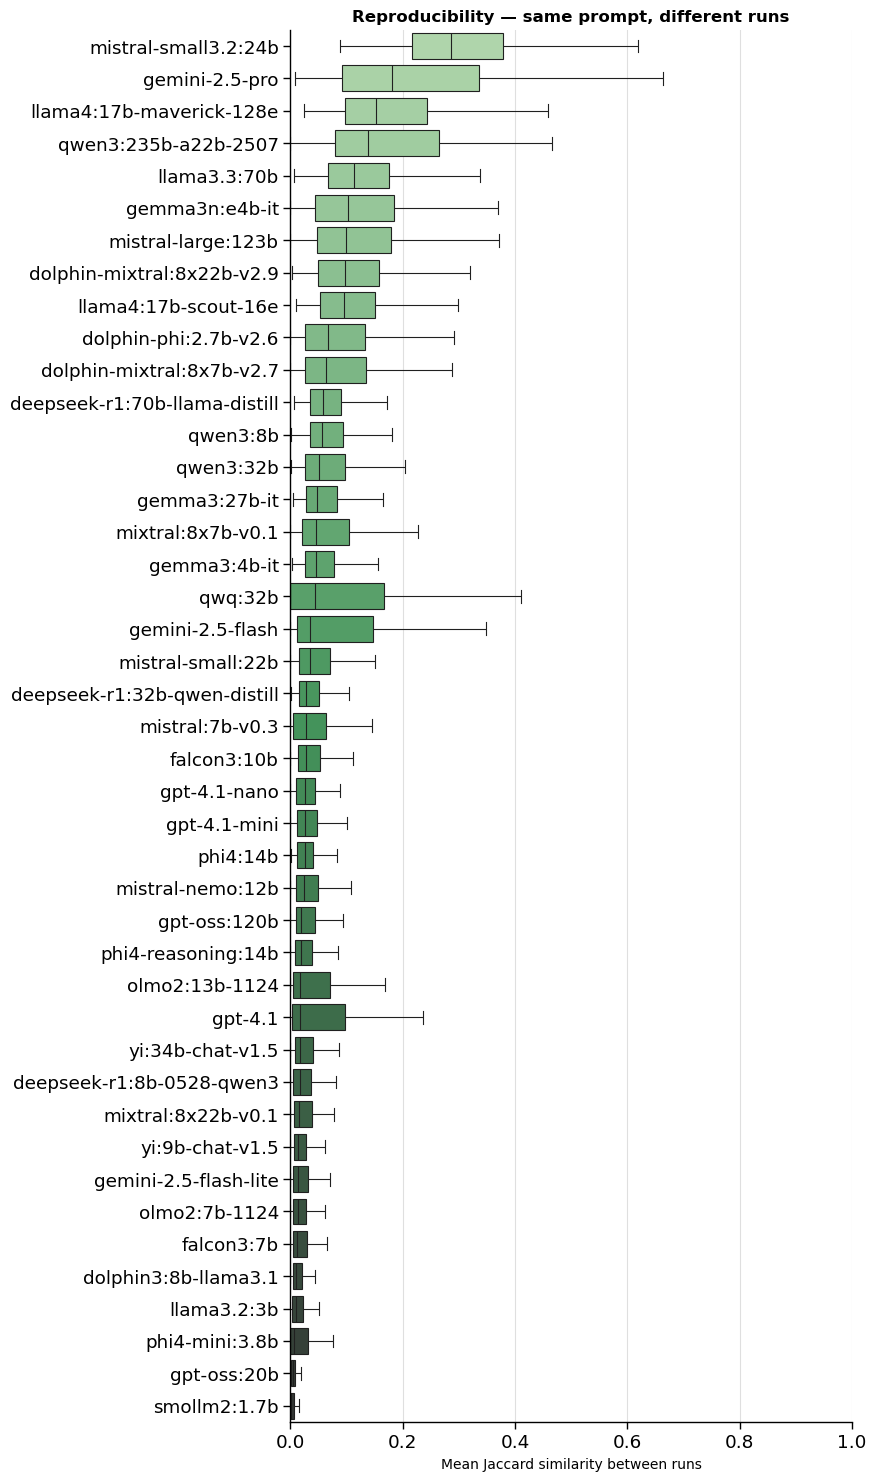

In [28]:
rep_df['model_clean'] = rep_df['model'].map(clean_model)
model_order_rep = (rep_df.groupby('model_clean')['mean_jaccard']
                   .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(9, max(5, len(model_order_rep) * 0.35)))
sns.boxplot(data=rep_df, y='model_clean', x='mean_jaccard',
            order=model_order_rep, orient='h',
            palette='Greens_d', showfliers=False, linewidth=0.8, ax=ax)
ax.set_xlim(0, 1)
ax.set_xlabel('Mean Jaccard similarity between runs', fontsize=10)
ax.set_ylabel('')
ax.set_title('Reproducibility — same prompt, different runs',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.show()

## 14. Figure 2 — Persona-level Performance (Figure 2-style)

In [29]:

# ── Normalize persona dimensions ─────────────────────────────────────────────
LOCATION_MAP = {
    'Germany': 'Germany', 'Deutschland': 'Germany', 'Alemania': 'Germany',
    'Canada': 'Canada', 'Canadá': 'Canada', 'Kanada': 'Canada',
    'Japan': 'Japan', 'Japón': 'Japan',
    'South Africa': 'South Africa', 'Sudáfrica': 'South Africa', 'Südafrika': 'South Africa',
    'Ecuador': 'Ecuador',
}
ROLE_MAP = {
    'Director/Recruiter':           'Director/Recruiter',
    'Director(a)/Reclutador(a)':    'Director/Recruiter',
    'Direktor(in)/Rekrutierende(r)':'Director/Recruiter',
    'PhD student':                  'PhD Student',
    'Estudiante de doctorado':      'PhD Student',
    'Doktorand(in)':                'PhD Student',
}
LANG_MAP = {'english': 'English', 'german': 'German', 'spanish': 'Spanish'}

df2 = df.copy()
df2['country']    = df2['location'].map(LOCATION_MAP)
df2['role_canon'] = df2['role'].map(ROLE_MAP)
df2['lang_canon'] = df2['language'].map(LANG_MAP)

# ── Per-row binary metrics ────────────────────────────────────────────────────
df2['refused'] = (df2['valid_flag'] == 'refused').astype(float)
df2['valid']   = df2['valid_flag'].isin(['unchanged', 'cleaned', 'fixed_dict']).astype(float)
df2['found']   = (df2['author_status'] == 'found').astype(float)

found2 = df2[df2['author_status'] == 'found'].copy()
found2['field_match']    = (found2['field_status']    == 'field_match').astype(float)
found2['seniority_match']= (found2['seniority_status']== 'seniority_match').astype(float)
found2['location_match'] = (found2['location_status'] == 'location_match').astype(float)

print("df2 rows:", len(df2), "  found2 rows:", len(found2))


df2 rows: 3907448   found2 rows: 1757396


Saved → results/factualities_v2/figures/figure2_persona_performance.{pdf,png}


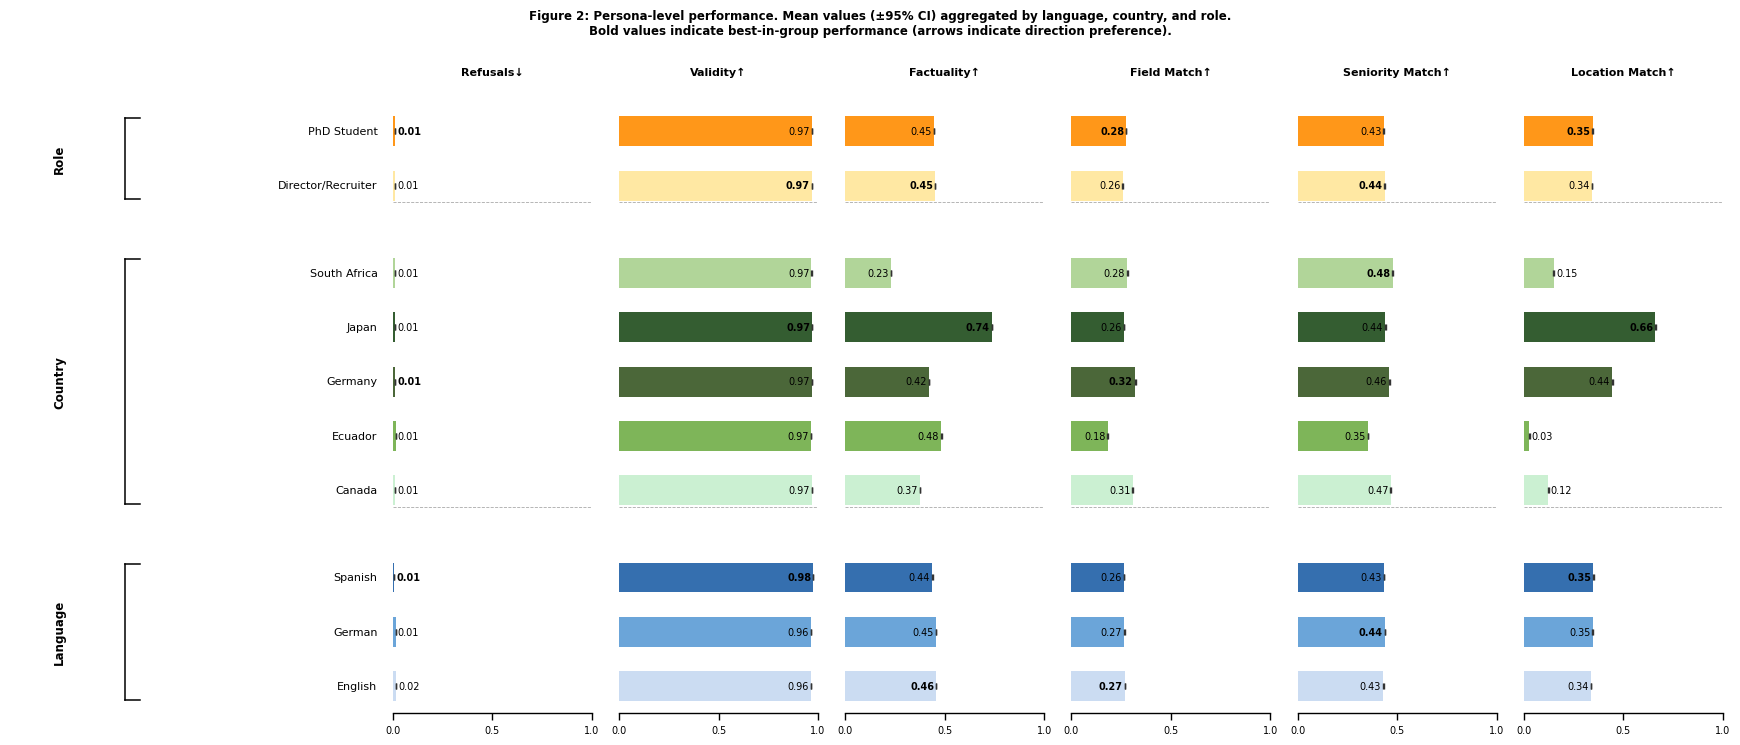

In [30]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Config ────────────────────────────────────────────────────────────────────
GROUPS = [
    {
        'name':  'Language',
        'col':   'lang_canon',
        'order': ['English', 'German', 'Spanish'],
        'colors':['#C6D9F1', '#5B9BD5', '#1F5FA6'],
    },
    {
        'name':  'Country',
        'col':   'country',
        'order': ['Canada', 'Ecuador', 'Germany', 'Japan', 'South Africa'],
        'colors':['#C6EFCE', '#70AD47', '#375623', '#1E4B1A', '#A9D18E'],
    },
    {
        'name':  'Role',
        'col':   'role_canon',
        'order': ['Director/Recruiter', 'PhD Student'],
        'colors':['#FFE699', '#FF8C00'],
    },
]

METRICS = [
    {'label': 'Refusals↓',        'col': 'refused',          'data': 'all',   'better': 'low'},
    {'label': 'Validity↑',        'col': 'valid',            'data': 'all',   'better': 'high'},
    {'label': 'Factuality↑',      'col': 'found',            'data': 'all',   'better': 'high'},
    {'label': 'Field Match↑',     'col': 'field_match',      'data': 'found', 'better': 'high'},
    {'label': 'Seniority Match↑', 'col': 'seniority_match',  'data': 'found', 'better': 'high'},
    {'label': 'Location Match↑',  'col': 'location_match',   'data': 'found', 'better': 'high'},
]

GROUP_GAP = 0.6
BAR_H     = 0.55

def mean_ci95(series):
    s = series.dropna()
    n = len(s)
    if n == 0:
        return np.nan, np.nan
    m = s.mean()
    ci = 1.96 * np.sqrt(m * (1 - m) / n)
    return m, ci

# ── Build ordered rows ────────────────────────────────────────────────────────
rows = []
y = 0
group_spans = {}
for g in GROUPS:
    y_start = y
    for i, item in enumerate(g['order']):
        rows.append({
            'group':     g['name'],
            'label':     item,
            'y':         y,
            'color':     g['colors'][i % len(g['colors'])],
            'col_group': g['col'],
        })
        y += 1
    group_spans[g['name']] = (y_start, y - 1)
    y += GROUP_GAP

y_max = y - GROUP_GAP

# ── Figure layout ─────────────────────────────────────────────────────────────
n_metrics  = len(METRICS)
left_frac  = 0.22
fig_w      = 3 + n_metrics * 2.4
fig_h      = y_max * 0.58 + 1.2

fig = plt.figure(figsize=(fig_w, fig_h))

axes = []
for i in range(n_metrics):
    left_pos  = left_frac + i * (1 - left_frac) / n_metrics
    width_pos = (1 - left_frac) / n_metrics * 0.88
    ax = fig.add_axes([left_pos, 0.08, width_pos, 0.82])
    axes.append(ax)

# ── Plot bars ─────────────────────────────────────────────────────────────────
for ax_i, (ax, metric) in enumerate(zip(axes, METRICS)):
    # Select correct data source for this metric
    src = df2 if metric['data'] == 'all' else found2

    # Compute stats per row
    vals = []
    for row in rows:
        d = src[src[row['col_group']] == row['label']][metric['col']]
        vals.append(mean_ci95(d))

    # Best value per group
    best_per_group = {}
    for g in GROUPS:
        g_vals = [v[0] for r, v in zip(rows, vals)
                  if r['group'] == g['name'] and not np.isnan(v[0])]
        if g_vals:
            best_per_group[g['name']] = min(g_vals) if metric['better'] == 'low' else max(g_vals)

    for row, (m, ci) in zip(rows, vals):
        y_pos = row['y']
        if np.isnan(m):
            continue

        best    = best_per_group.get(row['group'], np.nan)
        is_best = (not np.isnan(best)) and (abs(m - best) < 1e-9)

        ax.barh(y_pos, m, height=BAR_H, color=row['color'], alpha=0.9, zorder=2)
        ax.errorbar(m, y_pos, xerr=ci, fmt='none', color='#333333',
                    linewidth=0.9, capsize=2, zorder=3)

        txt    = f"{m:.2f}"
        x_text = max(m - ci - 0.01, 0.01) if m > 0.15 else m + ci + 0.01
        ha     = 'right' if m > 0.15 else 'left'
        ax.text(x_text, y_pos, txt, ha=ha, va='center', fontsize=7,
                fontweight='bold' if is_best else 'normal', color='black', zorder=4)

    # Group separator lines
    prev_group = None
    for row in rows:
        if prev_group is not None and row['group'] != prev_group:
            ax.axhline(row['y'] - GROUP_GAP / 2, color='#AAAAAA',
                       linewidth=0.6, linestyle='--', zorder=1)
        prev_group = row['group']

    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, y_max - GROUP_GAP + 0.5)
    ax.set_yticks([])
    ax.set_xticks([0, 0.5, 1.0])
    ax.tick_params(axis='x', labelsize=7)
    ax.spines[['left', 'right', 'top']].set_visible(False)
    ax.set_title(metric['label'], fontsize=8, fontweight='bold', pad=5)

# ── Left-side labels ──────────────────────────────────────────────────────────
lax = fig.add_axes([0.0, 0.08, left_frac, 0.82])
lax.set_xlim(0, 1)
lax.set_ylim(-0.5, y_max - GROUP_GAP + 0.5)
lax.axis('off')

for row in rows:
    lax.text(0.96, row['y'], row['label'], ha='right', va='center', fontsize=8)

BRACKET_X = 0.30
for g in GROUPS:
    y0, y1  = group_spans[g['name']]
    mid_y   = (y0 + y1) / 2
    lax.text(0.13, mid_y, g['name'], ha='center', va='center',
             fontsize=8.5, fontweight='bold', rotation=90)
    lax.plot([BRACKET_X, BRACKET_X], [y0 - 0.25, y1 + 0.25], color='black', linewidth=1.1)
    lax.plot([BRACKET_X, BRACKET_X + 0.04], [y0 - 0.25, y0 - 0.25], color='black', linewidth=1.1)
    lax.plot([BRACKET_X, BRACKET_X + 0.04], [y1 + 0.25, y1 + 0.25], color='black', linewidth=1.1)

fig.suptitle(
    'Figure 2: Persona-level performance. Mean values (±95% CI) aggregated by language, country, and role.\n'
    'Bold values indicate best-in-group performance (arrows indicate direction preference).',
    fontsize=8.5, fontweight='bold', y=0.995, va='top'
)

out_dir = Path('../../../results/factualities_v2/figures')
out_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(out_dir / 'figure2_persona_performance.pdf', bbox_inches='tight', dpi=200)
fig.savefig(out_dir / 'figure2_persona_performance.png', bbox_inches='tight', dpi=200)
print("Saved → results/factualities_v2/figures/figure2_persona_performance.{pdf,png}")
plt.show()


## 15. OpenAlex Disaggregation & CSV Export

In [31]:

def rate(series, positive_val, evaluable_vals=None):
    """Fraction of evaluable rows where series == positive_val.

    evaluable_vals: if given, only rows with those values count toward the
    denominator (excludes 'not_applicable', 'field_unknown', etc.).
    """
    if evaluable_vals is not None:
        s = series[series.isin(evaluable_vals)]
    else:
        s = series.dropna()
    return (s == positive_val).sum() / len(s) if len(s) else np.nan

def summary_table(data, group_col, metrics: dict, min_n=30) -> pd.DataFrame:
    rows = []
    for val, g in data.groupby(group_col, dropna=True):
        row = {group_col: val, 'n': len(g)}
        for name, spec in metrics.items():
            col, pos = spec[0], spec[1]
            ev = spec[2] if len(spec) > 2 else None
            row[name] = rate(g[col], pos, ev)
        rows.append(row)
    out = pd.DataFrame(rows)
    return out[out['n'] >= min_n].sort_values('n', ascending=False).reset_index(drop=True)

METRICS_DEF = {
    'found_rate':      ('author_status',   'found'),
    'field_match':     ('field_status',    'field_match',
                        ['field_match', 'field_mismatch']),
    'seniority_match': ('seniority_status','seniority_match',
                        ['seniority_match', 'seniority_mismatch']),
    'location_match':  ('location_status', 'location_match',
                        ['location_match', 'location_mismatch']),
}

# author_source derived from existing columns. factuality_full.csv does not
# ship a pre-computed author_source — only author_status (SS match) and
# oa_status (OA match). We combine them into the 4-valued source label:
#   'semantic_scholar'                  → matched only in Semantic Scholar
#   'openalex_duckdb'                   → matched only in OpenAlex
#   'semantic_scholar+openalex_duckdb'  → matched in both
#   'none'                              → matched in neither (hallucinated)
in_ss = df['author_status'] == 'found'
in_oa = df['oa_status']     == 'found'
df['author_source'] = 'none'
df.loc[ in_ss & ~in_oa, 'author_source'] = 'semantic_scholar'
df.loc[~in_ss &  in_oa, 'author_source'] = 'openalex_duckdb'
df.loc[ in_ss &  in_oa, 'author_source'] = 'semantic_scholar+openalex_duckdb'

print("author_source distribution:")
print(df['author_source'].value_counts())


author_source distribution:
author_source
semantic_scholar+openalex_duckdb    1423318
none                                1206187
openalex_duckdb                      943865
semantic_scholar                     334078
Name: count, dtype: int64


### 15a. Coverage by data source — SS vs OA vs both vs none

In [32]:

# Binary source flags for each row
df['in_ss'] = df['author_source'].isin(['semantic_scholar', 'semantic_scholar+openalex_duckdb'])
df['in_oa'] = df['author_source'].isin(['openalex_duckdb',  'semantic_scholar+openalex_duckdb'])
df['in_both'] = df['author_source'] == 'semantic_scholar+openalex_duckdb'
df['in_none'] = df['author_source'] == 'none'

# Overall coverage summary
total = len(df)
summary = pd.DataFrame({
    'count': {
        'Found in Semantic Scholar only':   (df['author_source'] == 'semantic_scholar').sum(),
        'Found in OpenAlex only':           (df['author_source'] == 'openalex_duckdb').sum(),
        'Found in both (SS + OA)':          (df['author_source'] == 'semantic_scholar+openalex_duckdb').sum(),
        'Not found (hallucinated)':         (df['author_source'] == 'none').sum(),
    }
})
summary['fraction'] = summary['count'] / total
display(summary)


,count,fraction
Found in Semantic Scholar only,334078,0.1
Found in OpenAlex only,943865,0.2
Found in both (SS + OA),1423318,0.4
Not found (hallucinated),1206187,0.3


### 15b. Source coverage by persona dimension (model / language / country)

In [33]:

SOURCE_METRICS = {
    'ss_rate':   ('in_ss',   True),
    'oa_rate':   ('in_oa',   True),
    'both_rate': ('in_both', True),
    'none_rate': ('in_none', True),
}

for dim in ['model', 'language', 'location']:
    print(f'\n=== by {dim} ===')
    display(summary_table(df, dim, SOURCE_METRICS, min_n=100))



=== by model ===


,model,n,ss_rate,oa_rate,both_rate,none_rate
0,llama4:17b-scout-16e-instruct-q4_K_M,121885,0.5,0.7,0.5,0.3
1,falcon3:10b-instruct-q4_K_M,116369,0.6,0.9,0.5,0.1
2,mistral:7b-instruct-v0.3-q4_K_M,115816,0.2,0.1,0.0,0.7
3,phi4:14b-q4_K_M,115276,0.5,0.8,0.5,0.2
4,llama3.3:70b-instruct-q4_K_M,115202,0.6,0.9,0.5,0.1
5,dolphin3:8b-llama3.1-q4_K_M,115126,0.4,0.4,0.2,0.4
6,mistral-small3.2:24b-instruct-2506-q4_K_M,115116,0.5,0.9,0.5,0.1
7,gpt-4.1-2025-04-14,114943,0.4,0.7,0.4,0.3
8,gemini-2.5-pro,114844,0.5,0.7,0.4,0.2
9,gemini-2.5-flash-lite,114803,0.5,0.7,0.4,0.3



=== by language ===


,language,n,ss_rate,oa_rate,both_rate,none_rate
0,spanish,1363849,0.4,0.6,0.4,0.3
1,english,1312843,0.5,0.6,0.4,0.3
2,german,1230756,0.5,0.6,0.4,0.3



=== by location ===


,location,n,ss_rate,oa_rate,both_rate,none_rate
0,Ecuador,773190,0.5,0.7,0.5,0.3
1,Japan,513195,0.7,0.7,0.6,0.2
2,Japón,275768,0.7,0.7,0.6,0.2
3,Alemania,274207,0.4,0.6,0.3,0.3
4,Canadá,271601,0.4,0.6,0.3,0.3
5,Sudáfrica,271199,0.2,0.4,0.2,0.5
6,Germany,263902,0.4,0.6,0.3,0.3
7,Canada,262540,0.4,0.6,0.3,0.3
8,South Africa,262182,0.2,0.4,0.2,0.5
9,Deutschland,247525,0.4,0.6,0.3,0.3


### 15c. Factuality metrics split by source: SS-only vs OA-only vs both

In [34]:

FACT_METRICS = {k: v for k, v in METRICS_DEF.items() if k != 'found_rate'}

subsets = {
    'SS only':   df[df['author_source'] == 'semantic_scholar'],
    'OA only':   df[df['author_source'] == 'openalex_duckdb'],
    'SS + OA':   df[df['author_source'] == 'semantic_scholar+openalex_duckdb'],
    'All found': df[df['author_status'] == 'found'],
}

for dim in ['model', 'language', 'location']:
    rows = []
    for src_label, subset in subsets.items():
        for val, g in subset.groupby(dim, dropna=True):
            if len(g) < 30:
                continue
            row = {'source': src_label, dim: val, 'n': len(g)}
            for name, spec in FACT_METRICS.items():
                col, pos = spec[0], spec[1]
                ev = spec[2] if len(spec) > 2 else None
                row[name] = rate(g[col], pos, ev)
            rows.append(row)
    t = pd.DataFrame(rows).sort_values(['source', 'n'], ascending=[True, False])
    print(f'\n=== Factuality by source × {dim} ===')
    display(t)



=== Factuality by source × model ===


,source,model,n,field_match,seniority_match,location_match
136,All found,falcon3:10b-instruct-q4_K_M,66829,0.2,0.6,0.4
150,All found,llama3.3:70b-instruct-q4_K_M,63491,0.3,0.5,0.5
155,All found,mistral-small3.2:24b-instruct-2506-q4_K_M,61144,0.3,0.5,0.4
152,All found,llama4:17b-scout-16e-instruct-q4_K_M,60892,0.2,0.6,0.4
147,All found,gpt-oss:120b,57700,0.3,0.6,0.5
...,...,...,...,...,...,...
37,SS only,qwen3:32b-q4_K_M,799,0.4,0.8,NaN
24,SS only,mistral-large:123b-instruct-2411-q4_K_M,621,0.4,0.8,NaN
3,SS only,dolphin-mixtral:8x22b-v2.9-q4_K_M,589,0.3,0.8,NaN
36,SS only,qwen3:235b-a22b-instruct-2507-q4_K_M,279,0.4,0.8,NaN



=== Factuality by source × language ===


,source,language,n,field_match,seniority_match,location_match
9,All found,english,600062,0.3,0.6,0.4
11,All found,spanish,597443,0.3,0.6,0.4
10,All found,german,559891,0.3,0.6,0.4
5,OA only,spanish,337023,NaN,NaN,NaN
3,OA only,english,308606,NaN,NaN,NaN
4,OA only,german,298236,NaN,NaN,NaN
8,SS + OA,spanish,492795,0.3,0.6,0.4
6,SS + OA,english,473097,0.3,0.5,0.4
7,SS + OA,german,457426,0.3,0.6,0.4
0,SS only,english,126965,0.3,0.6,NaN



=== Factuality by source × location ===


,source,location,n,field_match,seniority_match,location_match
42,All found,Japan,384353,0.3,0.6,0.9
40,All found,Ecuador,373372,0.2,0.5,0.0
43,All found,Japón,197515,0.3,0.6,0.9
36,All found,Alemania,114138,0.3,0.6,0.6
41,All found,Germany,112503,0.3,0.6,0.6
39,All found,Deutschland,103567,0.3,0.6,0.6
37,All found,Canada,99263,0.3,0.6,0.2
38,All found,Canadá,98820,0.3,0.6,0.2
44,All found,Kanada,94365,0.3,0.6,0.1
45,All found,South Africa,62655,0.3,0.6,0.2


### 15d. OA-specific metadata — only for authors verified via OpenAlex

In [35]:

df_oa = df[df['in_oa']].copy()
print(f"Authors verified via OA: {len(df_oa):,}  (of which also in SS: {df_oa['in_both'].sum():,})")

display(summary_table(df_oa, 'oa_country_code', FACT_METRICS, min_n=50).head(20))

h_valid = df_oa['oa_h_index'].dropna()
print(f"\nOA-verified with h_index: {len(h_valid):,}")
if len(h_valid) >= 40:
    df_oa = df_oa.copy()
    df_oa.loc[h_valid.index, 'h_quartile'] = pd.qcut(
        h_valid, q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'], duplicates='drop'
    )
    display(summary_table(df_oa, 'h_quartile', FACT_METRICS, min_n=10))


Authors verified via OA: 2,367,183  (of which also in SS: 1,423,318)


,oa_country_code,n,field_match,seniority_match,location_match
0,US,537024,0.3,0.5,0.0
1,JP,459614,0.3,0.5,1.0
2,DE,291064,0.3,0.6,0.9
3,ES,165952,0.2,0.5,0.0
4,GB,132400,0.2,0.5,0.0
5,CA,102058,0.5,0.7,0.8
6,ZA,97274,0.4,0.6,0.9
7,MX,47349,0.2,0.5,0.0
8,CH,47203,0.2,0.5,0.0
9,AU,32683,0.3,0.6,0.0



OA-verified with h_index: 0


### 15e. Master export — model × language × location × field, split by source

In [36]:

GROUP_KEYS = ['model', 'language', 'location', 'field']

master_rows = []
for keys, g in df.groupby(GROUP_KEYS, dropna=False):
    base = dict(zip(GROUP_KEYS, keys))
    base['n_total'] = len(g)
    base['found_rate'] = rate(g['author_status'], 'found')
    base['ss_rate']    = rate(g['in_ss'],   True)
    base['oa_rate']    = rate(g['in_oa'],   True)
    base['both_rate']  = rate(g['in_both'], True)
    base['none_rate']  = rate(g['in_none'], True)

    for src_label, mask_col in [('ss', 'in_ss'), ('oa', 'in_oa'), ('all', None)]:
        sub = g[g[mask_col]] if mask_col else g[g['author_status'] == 'found']
        for name, spec in FACT_METRICS.items():
            col, pos = spec[0], spec[1]
            ev = spec[2] if len(spec) > 2 else None
            base[f'{name}_{src_label}'] = rate(sub[col], pos, ev)

    oa_sub = g[g['in_oa']]
    for oc in ['oa_h_index', 'oa_cited_by_count', 'oa_career_age', 'oa_works_count']:
        base[f'median_{oc}'] = oa_sub[oc].median() if oc in oa_sub.columns else np.nan

    master_rows.append(base)

master = pd.DataFrame(master_rows)
print(f'Master: {len(master):,} rows × {len(master.columns)} columns')
display(master.head(10))


Master: 3,870 rows × 23 columns


,model,language,location,field,n_total,found_rate,ss_rate,oa_rate,both_rate,none_rate,field_match_ss,seniority_match_ss,location_match_ss,field_match_oa,seniority_match_oa,location_match_oa,field_match_all,seniority_match_all,location_match_all,median_oa_h_index,median_oa_cited_by_count,median_oa_career_age,median_oa_works_count
0,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Biology,1020,0.5,0.5,0.9,0.4,0.1,0.5,0.6,0.1,0.5,0.6,0.1,0.5,0.6,0.1,NaN,7576.0,52.0,153.0
1,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Computer Science,974,0.4,0.4,0.9,0.4,0.1,0.3,0.4,0.1,0.3,0.4,0.1,0.3,0.4,0.1,NaN,8844.0,42.0,198.0
2,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Mathematics,1010,0.4,0.4,0.9,0.4,0.1,0.2,0.6,0.2,0.2,0.5,0.2,0.2,0.6,0.2,NaN,3848.5,49.0,98.0
3,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Physics,945,0.4,0.4,0.9,0.4,0.1,0.1,0.5,0.1,0.1,0.5,0.1,0.1,0.5,0.1,NaN,7280.5,53.0,130.5
4,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Psychology,1066,0.4,0.4,0.8,0.3,0.2,0.3,0.5,0.2,0.3,0.5,0.2,0.3,0.5,0.2,NaN,6010.0,46.0,135.0
5,deepseek-r1:32b-qwen-distill-q4_K_M,english,Canada,Sociology,1006,0.4,0.4,0.9,0.3,0.1,0.0,0.6,0.1,0.0,0.6,0.1,0.0,0.6,0.1,NaN,6010.0,49.0,110.0
6,deepseek-r1:32b-qwen-distill-q4_K_M,english,Ecuador,Biology,849,0.6,0.6,0.8,0.5,0.2,0.7,0.5,0.0,0.7,0.5,0.0,0.7,0.5,0.0,NaN,2117.0,31.5,79.0
7,deepseek-r1:32b-qwen-distill-q4_K_M,english,Ecuador,Computer Science,941,0.6,0.6,0.9,0.6,0.1,0.1,0.4,0.0,0.1,0.4,0.0,0.1,0.4,0.0,NaN,1734.0,30.0,69.0
8,deepseek-r1:32b-qwen-distill-q4_K_M,english,Ecuador,Mathematics,934,0.6,0.6,0.9,0.6,0.1,0.0,0.5,0.1,0.0,0.5,0.1,0.0,0.5,0.1,NaN,1758.0,32.0,83.5
9,deepseek-r1:32b-qwen-distill-q4_K_M,english,Ecuador,Physics,946,0.6,0.6,0.9,0.6,0.1,0.1,0.5,0.1,0.1,0.5,0.1,0.1,0.5,0.1,NaN,1976.5,33.0,90.5
